# Notebook23 - SDL Learning Engine and Closed-Loop Feedback System

## Purpose

Previous notebooks completed one full SDL cycle:

1. Clone generation
2. Multi-objective scoring
3. Candidate selection
4. Engineering recommendation
5. Experimental simulation

However, true SDL systems do not stop after experiments.

They learn.

This notebook implements the LEARN phase of the Design-Build-Test-Learn (DBTL) cycle.

The goal is to compare predicted outcomes against simulated experimental outcomes and generate learning signals that improve future decisions.

## Key Questions

- How accurate were our predictions?
- Which interventions performed better than expected?
- Which interventions performed worse than expected?
- How much prediction error exists?
- What can the platform learn from completed experiments?

## Expected Outputs

- Prediction error analysis
- Intervention performance calibration
- SDL learning database
- Knowledge update factors
- Closed-loop learning metrics

This notebook transforms the platform from a prediction engine into a self-improving SDL system.

# Section 1 - Load Experimental Outcomes

This section loads results generated in Notebook22.

These represent completed simulated experiments and will serve as the learning source for the SDL platform.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]

results = pd.read_csv(
    ROOT /
    "data/synthetic/digital_twin/" /
    "notebook22_engineering_experimental_outcomes_5000_legacy.csv"
)

print(results.shape)

results.head()

(36, 40)


,clone_id,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,decision,bottleneck,recommended_intervention,...,titer_after_g_L,qp_after_pg_cell_day,stability_after_pct,quality_after_pct,delta_titer_g_L,delta_qp_pg_cell_day,delta_stability_pct,delta_quality_pct,experimental_roi_score,engineering_result_class
0,CLONE_4625,59.323924,100.000000,69.850174,83.065313,17.302240,58.422895,Advance,omics,PDI_folding_support,...,6.882502,41.701048,91.539428,87.838499,0.258323,1.283321,0.046261,2.986326,1.894724,Neutral / Small Change
1,CLONE_4878,51.055084,79.679015,66.381308,69.204240,11.833808,63.761372,Advance,omics,PDI_folding_support,...,5.274598,25.839835,91.023864,80.119588,-0.174786,-3.738110,1.596965,-2.611669,-5.594832,Negative Outcome
2,CLONE_3895,42.862936,1.170372,98.964170,82.267468,28.517580,79.479074,Advance,productivity,XBP1s_secretory_support,...,1.854280,3.745881,81.842530,89.574252,0.133839,-1.972266,-4.179618,-3.153157,-3.345842,Negative Outcome
3,CLONE_3895,42.631425,1.170372,98.607662,82.267468,28.517580,78.902602,Advance with Monitoring,productivity,XBP1s_secretory_support,...,2.370905,9.725536,94.338296,96.272419,0.431629,0.957294,1.432854,-0.089771,2.963176,Neutral / Small Change
4,CLONE_3895,42.595722,1.170372,98.964170,82.267468,26.736152,79.479074,Advance with Monitoring,productivity,XBP1s_secretory_support,...,1.656397,12.491053,92.266302,96.975757,0.156417,2.639601,0.830571,0.290345,1.715323,Neutral / Small Change


In [6]:
print(results.columns.tolist())

['clone_id', 'overall_score', 'score_productivity', 'score_quality', 'score_stability', 'omics_score', 'rl_robustness_score', 'decision', 'bottleneck', 'recommended_intervention', 'post_engineering_score', 'engineering_gain', 'success_probability', 'off_target_risk', 'engineering_complexity', 'engineering_success', 'realized_gain', 'engineering_confidence', 'expected_net_benefit', 'portfolio_group', 'titer_before_g_L', 'qp_before_pg_cell_day', 'stability_before_pct', 'quality_before_pct', 'experimental_outcome', 'response_multiplier', 'base_titer_frac', 'base_qp_frac', 'base_stability_delta', 'base_quality_delta', 'titer_after_g_L', 'qp_after_pg_cell_day', 'stability_after_pct', 'quality_after_pct', 'delta_titer_g_L', 'delta_qp_pg_cell_day', 'delta_stability_pct', 'delta_quality_pct', 'experimental_roi_score', 'engineering_result_class']


# Section 2 - Prediction Error Calculation

The SDL platform learns by comparing predictions against observed outcomes.

Prediction Error:

Error = Experimental Outcome - Predicted Outcome

Positive:
Model underestimated performance

Negative:
Model overestimated performance

In [7]:
# Section 2 — Build SDL learning table from Notebook22 outputs

learning = results.copy()

required_cols = [
    "clone_id",
    "recommended_intervention",
    "overall_score",
    "post_engineering_score",
    "engineering_gain",
    "realized_gain",
    "success_probability",
    "off_target_risk",
    "engineering_complexity",
    "experimental_roi_score",
    "engineering_result_class",
]

missing_cols = [
    c for c in required_cols
    if c not in learning.columns
]

print("Missing columns:")
print(missing_cols)

assert len(missing_cols) == 0, "Required SDL learning columns are missing."

# Predicted value from Notebook20/21
learning["predicted_score"] = learning["post_engineering_score"]

# Observed experimental value from Notebook22
# ROI represents observed experimental value generated after engineering.
learning["observed_score"] = (
    learning["post_engineering_score"]
    + learning["experimental_roi_score"]
)

# Learning signal
learning["prediction_error"] = (
    learning["observed_score"]
    - learning["predicted_score"]
)

display(
    learning[
        [
            "clone_id",
            "recommended_intervention",
            "predicted_score",
            "observed_score",
            "prediction_error",
            "experimental_roi_score",
            "engineering_result_class",
        ]
    ].head()
)

Missing columns:
[]


,clone_id,recommended_intervention,predicted_score,observed_score,prediction_error,experimental_roi_score,engineering_result_class
0,CLONE_4625,PDI_folding_support,75.317352,77.212076,1.894724,1.894724,Neutral / Small Change
1,CLONE_4878,PDI_folding_support,65.778556,60.183724,-5.594832,-5.594832,Negative Outcome
2,CLONE_3895,XBP1s_secretory_support,60.658313,57.312471,-3.345842,-3.345842,Negative Outcome
3,CLONE_3895,XBP1s_secretory_support,62.177485,65.140661,2.963176,2.963176,Neutral / Small Change
4,CLONE_3895,XBP1s_secretory_support,58.627415,60.342738,1.715323,1.715323,Neutral / Small Change


# Section 3 - SDL Prediction Performance

This section evaluates overall prediction quality.

Metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Bias

These metrics quantify how well the SDL platform predicts experimental outcomes.

In [8]:
# Section 3 — SDL prediction performance

mae = learning["prediction_error"].abs().mean()

rmse = np.sqrt(
    np.mean(
        learning["prediction_error"] ** 2
    )
)

bias = learning["prediction_error"].mean()

performance_summary = pd.DataFrame(
    {
        "metric": [
            "MAE",
            "RMSE",
            "Bias",
        ],
        "value": [
            round(mae, 3),
            round(rmse, 3),
            round(bias, 3),
        ],
    }
)

display(performance_summary)

,metric,value
0,MAE,2.040
1,RMSE,2.435
2,Bias,-0.560


# Section 4 - Prediction Calibration

A perfect SDL system would place every clone on the diagonal line.

Points above the line:

Experimental result exceeded prediction.

Points below the line:

Experimental result underperformed prediction.

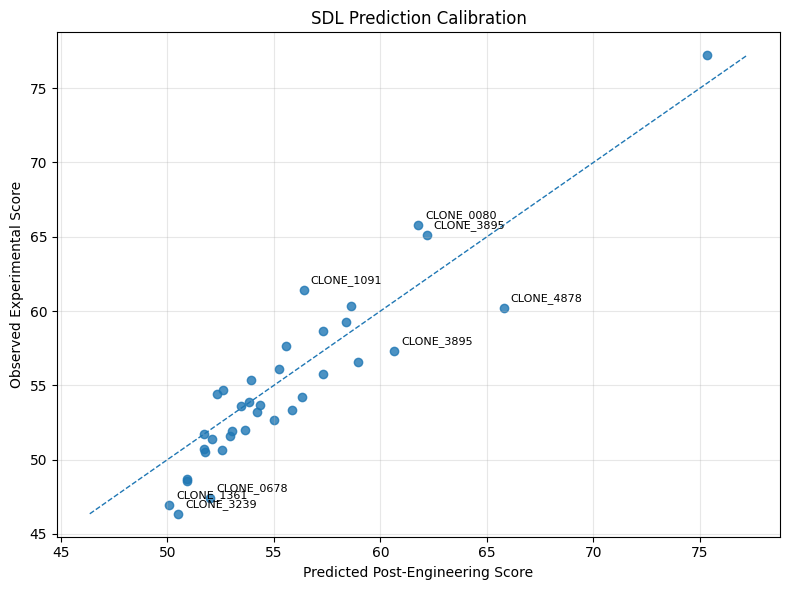

In [9]:
# Section 4 — Prediction calibration plot

plt.figure(figsize=(8, 6))

plt.scatter(
    learning["predicted_score"],
    learning["observed_score"],
    alpha=0.8,
)

min_val = min(
    learning["predicted_score"].min(),
    learning["observed_score"].min(),
)

max_val = max(
    learning["predicted_score"].max(),
    learning["observed_score"].max(),
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1,
)

for _, row in (
    learning
    .sort_values("prediction_error", key=abs, ascending=False)
    .head(8)
    .iterrows()
):
    plt.annotate(
        row["clone_id"],
        (
            row["predicted_score"],
            row["observed_score"],
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("SDL Prediction Calibration")
plt.xlabel("Predicted Post-Engineering Score")
plt.ylabel("Observed Experimental Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Section 5 - Intervention Learning Analysis

Not all interventions perform equally.

This section calculates average prediction error per intervention.

These results become learning signals for future SDL cycles.

In [10]:
# Section 5 — Intervention learning analysis

intervention_learning = (
    learning
    .groupby("recommended_intervention")
    .agg(
        n=("clone_id", "count"),
        mean_prediction_error=("prediction_error", "mean"),
        mean_absolute_error=("prediction_error", lambda x: x.abs().mean()),
        mean_expected_gain=("engineering_gain", "mean"),
        mean_realized_gain=("realized_gain", "mean"),
        mean_roi=("experimental_roi_score", "mean"),
        mean_success_probability=("success_probability", "mean"),
        mean_off_target_risk=("off_target_risk", "mean"),
    )
    .round(3)
    .sort_values("mean_roi", ascending=False)
)

display(intervention_learning)

,n,mean_prediction_error,mean_absolute_error,mean_expected_gain,mean_realized_gain,mean_roi,mean_success_probability,mean_off_target_risk
recommended_intervention,,,,,,,,
XBP1s_secretory_support,34,-0.485,1.940,16.134,13.371,-0.485,0.80,0.15
PDI_folding_support,2,-1.850,3.745,15.358,6.148,-1.850,0.75,0.20


# Section 6 - Success Probability Calibration

Notebook21 generated success probabilities.

This section evaluates whether those probabilities align with observed outcomes.

A successful intervention is defined as:

Experimental Score > Predicted Score

In [11]:
# Section 6 — Success probability calibration

learning["observed_success"] = learning["engineering_result_class"].isin(
    [
        "Major Improvement",
        "Moderate Improvement",
    ]
).astype(int)

success_calibration = (
    learning
    .groupby(
        pd.cut(
            learning["success_probability"],
            bins=4,
            include_lowest=True,
        )
    )
    .agg(
        predicted_success_probability=("success_probability", "mean"),
        observed_success_rate=("observed_success", "mean"),
        n=("clone_id", "count"),
    )
    .round(3)
)

display(success_calibration)

,predicted_success_probability,observed_success_rate,n
success_probability,,,
"(0.749, 0.762]",0.75,0.000,2
"(0.788, 0.8]",0.80,0.059,34


# Section 7 - Knowledge Update Engine

This section converts learning signals into adjustment factors.

Future SDL cycles can use these factors to refine intervention expectations.

This represents the LEARN component of the DBTL cycle.

In [12]:
# Section 7 — SDL knowledge update factors

knowledge_base = intervention_learning.reset_index()

knowledge_base["adjustment_factor"] = (
    1
    + knowledge_base["mean_prediction_error"] / 100
)

knowledge_base["adjustment_factor"] = (
    knowledge_base["adjustment_factor"]
    .clip(0.75, 1.25)
)

knowledge_base["future_priority_score"] = (
    knowledge_base["mean_roi"]
    * knowledge_base["mean_success_probability"]
    * (1 - knowledge_base["mean_off_target_risk"])
)

knowledge_base = (
    knowledge_base
    .sort_values("future_priority_score", ascending=False)
    .round(3)
)

display(knowledge_base)

,recommended_intervention,n,mean_prediction_error,mean_absolute_error,mean_expected_gain,mean_realized_gain,mean_roi,mean_success_probability,mean_off_target_risk,adjustment_factor,future_priority_score
0,XBP1s_secretory_support,34,-0.485,1.940,16.134,13.371,-0.485,0.80,0.15,0.995,-0.33
1,PDI_folding_support,2,-1.850,3.745,15.358,6.148,-1.850,0.75,0.20,0.982,-1.11


# Section 8 - Export Learning Outputs

This section saves learning outputs for future SDL cycles.

The exported files become the memory of the platform.

In [13]:
# Section 8 — Export SDL learning outputs

out_dir = ROOT / "data/synthetic/digital_twin"

learning.to_csv(
    out_dir / "notebook23_sdl_learning_database_5000_legacy.csv",
    index=False,
)

knowledge_base.to_csv(
    out_dir / "notebook23_intervention_knowledge_updates_5000_legacy.csv",
    index=False,
)

performance_summary.to_csv(
    out_dir / "notebook23_prediction_performance_summary_5000_legacy.csv",
    index=False,
)

success_calibration.to_csv(
    out_dir / "notebook23_success_probability_calibration_5000_legacy.csv",
)

print("Notebook23 SDL learning outputs saved.")

Notebook23 SDL learning outputs saved.


# Final Summary

This notebook implemented the LEARN phase of the SDL workflow.

Major achievements:

- Experimental outcome evaluation
- Prediction error quantification
- Model calibration assessment
- Intervention performance learning
- Success probability validation
- Knowledge update factor generation
- SDL memory database creation

The platform can now learn from completed experiments.

This transforms the system from a prediction engine into a self-improving SDL platform.

Workflow status:

Generate
→ Score
→ Select
→ Engineer
→ Simulate
→ Learn

The Design-Build-Test-Learn cycle is now complete.

# References

1. Design-Build-Test-Learn (DBTL) Framework
   National Academies of Sciences

2. Synthetic Biology Open Language (SBOL)
   Synthetic Biology Standards Consortium

3. Active Learning for Biological Engineering
   Nature Biotechnology

4. Self-Driving Laboratories
   Nature Reviews Bioengineering

5. Closed-Loop Optimization in Bioprocess Development
   Biotechnology Journal

6. Bayesian Learning and Experimental Feedback Systems
   Nature Machine Intelligence

7. Autonomous Biological Discovery Platforms
   Cell Systems